In [125]:
import matplotlib.pyplot as plt
import pandas as pd

In [127]:
# Lista dei frutti consentiti
frutti = ['fragole', 'mele', 'pere', 'ananas']

In [129]:
def crea_dataframe():
    """
    Crea un dataframe vuoto con le colonne nome, cognome, età e frutta
    """
    return pd.DataFrame(columns=['Nome', 'Cognome', 'Età', 'Frutta'])

In [131]:
def disegna_grafico(df):
    """
    Disegna un grafico a torta dei frutti consumati dai soggetti nel dataframe
    """
    frutta_count = df['Frutta'].value_counts()
    colori_mappa = {
        'fragole': '#ff6f61',
        'mele': '#6a0572',
        'ananas': '#f7b801',
        'pere': '#7fb069'
    }
    colori = [colori_mappa[f] for f in frutta_count.index]

    plt.figure(figsize=(3,3))
    plt.pie(
        frutta_count,
        labels=frutta_count.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colori,
    )
    plt.title("Grafico del consumo della frutta", fontsize=10)
    plt.show()

In [133]:
def acquisisci_soggetto(df):
    """
    Chiede all'utente di inserire i dati di un soggetto
    Restituisce:
      - 'stop' se l'utente scrive stop
      - 'duplicato' se il soggetto è già presente
      - dizionario con i dati del soggetto altrimenti
    """
    print("\nInserisci i dati del soggetto, o 'stop' per uscire dal programma")

    nome = input("Nome: ").strip()
    if nome.lower() == "stop":
        return 'stop'

    cognome = input("Cognome: ").strip()

    if ((df['Nome'] == nome) & (df['Cognome'] == cognome)).any():
        print("Questo soggetto è già presente nel database.")
        return 'duplicato'

    while True:
        try:
            eta = int(input("Età: "))
            if eta > 0:
                break
            print("Inserisci un'età valida.")
        except:
            print("Inserisci un numero intero valido.")

    while True:
        frutta = input(f"Frutta consumata {frutti}: ").strip().lower()
        if frutta in frutti:
            break
        print("Frutto non valido. Riprova.")

    return {'Nome': nome, 'Cognome': cognome, 'Età': eta, 'Frutta': frutta}


In [135]:
def aggiungi_soggetto(df, soggetto):
    """
    Aggiunge un soggetto al dataframe
    """
    return pd.concat([df, pd.DataFrame([soggetto])], ignore_index=True)

In [137]:
def salva_dataframe(df, percorso):
    """
    Salva il dataframe in un file csv
    """
    df.to_csv(percorso, index=True)
    print(f"File salvato in: {percorso}")

In [139]:
def inserisci_soggetti(df):
    """
    Gestisce l'inserimento fino a 10 soggetti,
    richiamando le funzioni acquisisci_soggetto, aggiungi_soggetto e disegna_grafico
    """
    count = 0
    while count <= 10:
        risultato = acquisisci_soggetto(df)

        if risultato == 'stop':
            print("Programma terminato.")
            break
        elif risultato == 'duplicato':
            print("Inserisci un nuovo soggetto.")
            continue

        df = aggiungi_soggetto(df, risultato)
        disegna_grafico(df)
        count += 1
    return df


Inserisci i dati del soggetto, o 'stop' per uscire dal programma


Nome:  chiara
Cognome:  verdi
Età:  8
Frutta consumata ['fragole', 'mele', 'pere', 'ananas']:  fragole


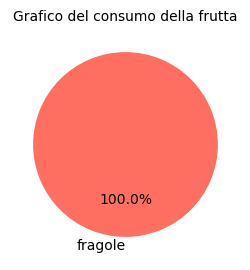


Inserisci i dati del soggetto, o 'stop' per uscire dal programma


Nome:  gaia
Cognome:  rossi
Età:  99
Frutta consumata ['fragole', 'mele', 'pere', 'ananas']:  mele


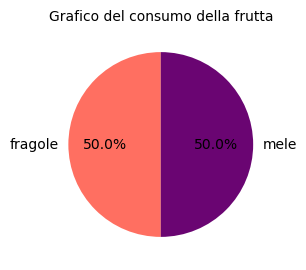


Inserisci i dati del soggetto, o 'stop' per uscire dal programma


Nome:  mario
Cognome:  azzurri
Età:  8
Frutta consumata ['fragole', 'mele', 'pere', 'ananas']:  pere


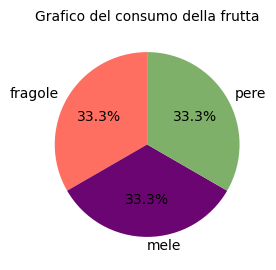


Inserisci i dati del soggetto, o 'stop' per uscire dal programma


Nome:  elena
Cognome:  viola
Età:  0


Inserisci un'età valida.


Età:  3
Frutta consumata ['fragole', 'mele', 'pere', 'ananas']:  ananas


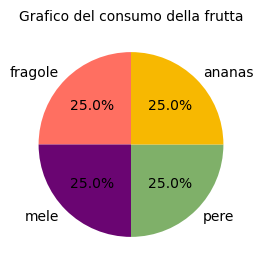


Inserisci i dati del soggetto, o 'stop' per uscire dal programma


Nome:  giorgio
Cognome:  giallo
Età:  47
Frutta consumata ['fragole', 'mele', 'pere', 'ananas']:  kiwi


Frutto non valido. Riprova.


In [ ]:
def main():
    df = crea_dataframe()
    df = inserisci_soggetti(df)
    print(f"\nNumero totale di record inseriti: {len(df)}")
    salva_dataframe(df,'/Users/chiarapareschi/Desktop/record_soggetti_frutta.csv')
main()